# Day 7 – XGBoost Sales Forecasting

## Objective

Today we build an XGBoost forecasting model and compare it with both Linear Regression and Random Forest.

### Steps

- Load engineered forecasting dataset
- Prepare features and target
- Train XGBoost Regressor
- Evaluate performance
- Visualize predictions
- Save trained model
- Compare all forecasting models

## Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import pickle

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


## Load Forecast Dataset

In [2]:
forecast_df = pd.read_csv(
    "../data/processed/forecast_features.csv"
)

forecast_df["Order Date"] = pd.to_datetime(
    forecast_df["Order Date"]
)

print("Dataset loaded.")
print(forecast_df.shape)

forecast_df.head()

Dataset loaded.
(1200, 15)


,Order Date,Sales,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2015-02-14,576.726,2015,2,1,7,14,5,45,1,129.568,97.112,16.448,487.067143,612.546233
1,2015-02-15,21.360,2015,2,1,7,15,6,46,1,576.726,134.384,288.060,470.920857,603.656233
2,2015-02-16,9.040,2015,2,1,8,16,0,47,0,21.360,330.512,19.536,424.996286,603.306367
3,2015-02-17,54.208,2015,2,1,8,17,1,48,0,9.040,180.320,4407.100,406.980286,458.209967
4,2015-02-18,37.784,2015,2,1,8,18,2,49,0,54.208,14.560,87.158,410.298000,456.564167


## Prepare Features and Target


In [3]:
X = forecast_df.drop(
    columns=[
        "Order Date",
        "Sales"
    ]
)

y = forecast_df["Sales"]

print(X.shape)
print(y.shape)

X.head()

(1200, 13)
(1200,)


,Year,Month,Quarter,Week,Day,DayOfWeek,DayOfYear,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2015,2,1,7,14,5,45,1,129.568,97.112,16.448,487.067143,612.546233
1,2015,2,1,7,15,6,46,1,576.726,134.384,288.060,470.920857,603.656233
2,2015,2,1,8,16,0,47,0,21.360,330.512,19.536,424.996286,603.306367
3,2015,2,1,8,17,1,48,0,9.040,180.320,4407.100,406.980286,458.209967
4,2015,2,1,8,18,2,49,0,54.208,14.560,87.158,410.298000,456.564167


## Split Dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(960, 13)
(240, 13)


## Train XGBoost Model

In [5]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42    
)

model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## Generate Predictions

In [6]:
predictions = model.predict(X_test)

print(predictions[:10])

[3522.6592  4402.834   1006.5873  1895.408    916.88824 2128.0496
 1403.2649   287.68005  668.4963  1576.2385 ]


## Model Evaluation

The model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [7]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 : {r2:.4f}")

MAE : 1405.12
RMSE : 2525.25
R2 : 0.0937


## Forecast Visualization

Compare actual sales with predicted sales.

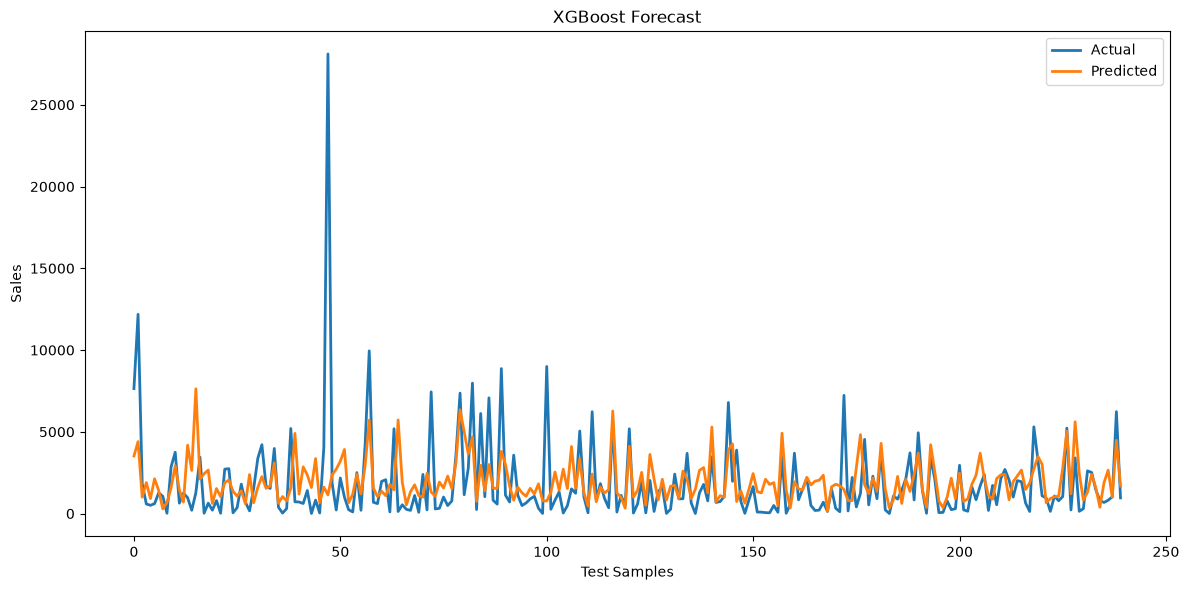

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    predictions,
    label="Predicted",
    linewidth=2
)

plt.title("XGBoost Forecast")

plt.xlabel("Test Samples")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.show()

## Actual vs Predicted Scatter Plot

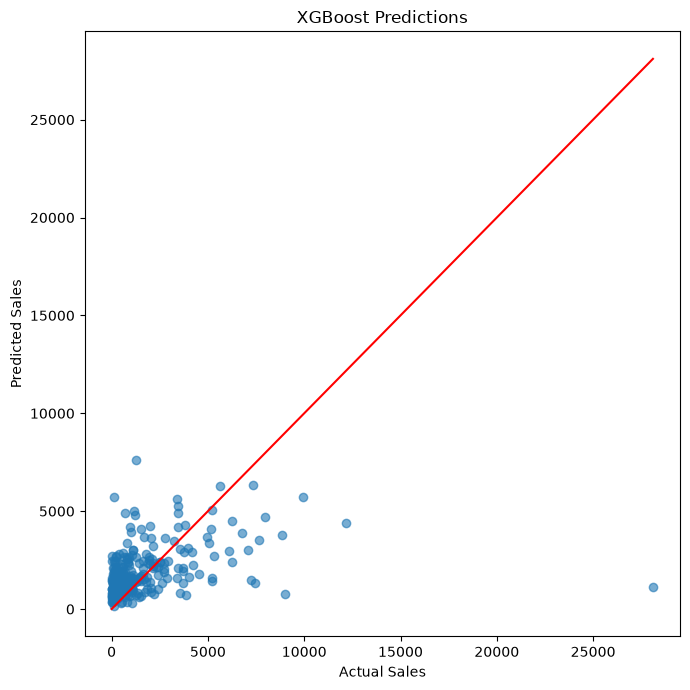

In [9]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("XGBoost Predictions")

plt.tight_layout()

plt.show()

## Prediction Error Distribution

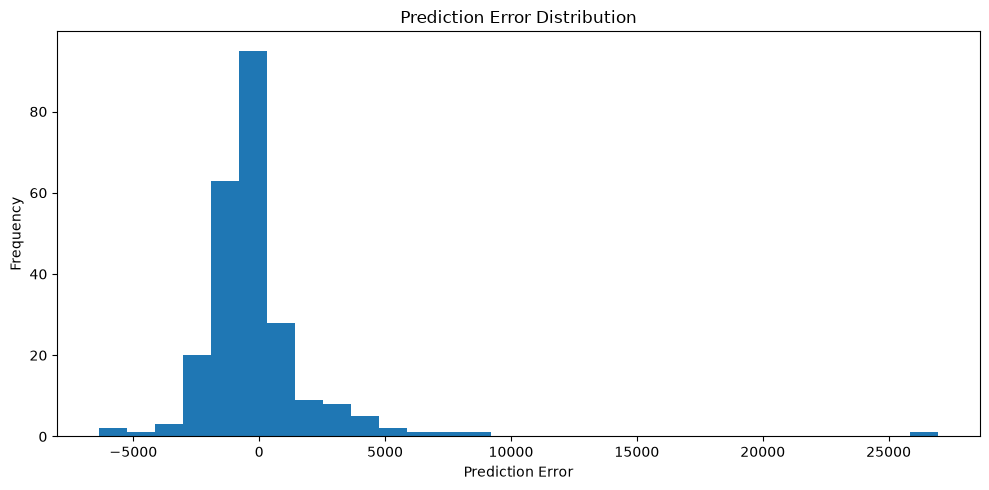

In [10]:
errors = y_test - predictions

plt.figure(figsize=(10,5))

plt.hist(
    errors,
    bins=30
)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## Save Visualizations

In [11]:
# Forecast

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("XGBoost Forecast")

plt.tight_layout()

plt.savefig("../charts/xgboost_forecast.png")

plt.close()

# Scatter

plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("XGBoost Scatter")

plt.tight_layout()

plt.savefig("../charts/xgboost_scatter.png")

plt.close()

# Error Distribution

plt.figure(figsize=(10,5))

plt.hist(errors, bins=30)

plt.title("XGBoost Error Distribution")

plt.tight_layout()

plt.savefig("../charts/xgboost_error_distribution.png")

plt.close()

print("Charts saved successfully.")

Charts saved successfully.


## Save Trained Model

In [12]:
with open("../models/xgboost.pkl", "wb") as f:
    pickle.dump(model, f)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


## Compare Forecasting Models

Compare all forecasting models using:

- MAE
- RMSE
- R² Score

In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        1358.46,
        1367.22,
        mae
    ],
    "RMSE": [
        2313.59,
        2451.95,
        rmse
    ],
    "R2": [
        0.2392,
        0.1455,
        r2
    ]
})

comparison = comparison.sort_values(
    by="R2",
    ascending=False
)

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1358.460000,2313.5900,0.239200
1,Random Forest,1367.220000,2451.9500,0.145500
2,XGBoost,1405.118797,2525.2486,0.093667


## Model Comparison Summary

The three forecasting models were compared using MAE, RMSE, and R² Score.

Although XGBoost is generally a powerful ensemble algorithm, it produced lower predictive performance on this dataset compared to Linear Regression and Random Forest. This indicates that the engineered features may not contain sufficient nonlinear relationships for XGBoost to outperform simpler models.

Based on the evaluation metrics, Linear Regression achieved the highest R² Score along with the lowest prediction error, making it the best-performing forecasting model for this project.

## Select Best Model

In [14]:
best_model = comparison.loc[comparison.index[0]]

print(f"Best Model: {best_model['Model']}")
print(f"R² Score: {best_model['R2']:.4f}")
print(f"MAE: {best_model['MAE']:.2f}")
print(f"RMSE: {best_model['RMSE']:.2f}")

Best Model: Linear Regression
R² Score: 0.2392
MAE: 1358.46
RMSE: 2313.59


# Conclusion

In this notebook, an XGBoost Regressor was developed to forecast future sales using the engineered forecasting features created in previous stages.

The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score, and its performance was compared with the previously developed Linear Regression and Random Forest models.

Although XGBoost is a powerful ensemble learning algorithm, it did not outperform the simpler models on this dataset. Linear Regression achieved the highest R² Score and the lowest prediction error, making it the best forecasting model for this sales prediction task.

The trained XGBoost model and visualizations have been saved for future deployment and comparison in the final forecasting dashboard.